In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import time

# ALgerian Products Data Scraping and Pre-Processing

The `modules/data_collection` module contains the scraping methods used to collect local product data from two market websites.  
The scraped data is extracted and saved into two CSV files:

- `data/products1.csv`
- `data/products2.csv`

These files store the products names, prices and categories gathered from each respective market source.

In [71]:
# only need to be runned once to generate products1.csv and products2.csv
# from modules.data_collection import scrape
# scrape()

The `products1.csv` and `products2.csv` files use different formats for storing product prices.  
For this reason, each dataset is loaded and preprocessed separately before merging or performing further analysis.

In [72]:
data1 = pd.read_csv("data/products1.csv")
data2 = pd.read_csv("data/products2.csv")

### `products1.csv` Pre-Processing

printing some insights from the data

In [73]:
data1.head(3)

,Name,Price,Category
0,Spaghetti 500g EXTRA,"90,00 د.ج",Pâtes et Couscous
1,Spaghetti 500g EXTRA,"90,00 د.ج",Pâtes et Couscous
2,FUSILLI 500g Garrido,"115,00 د.ج",Pâtes et Couscous


In [74]:
data1.duplicated().sum()

np.int64(189)

In [75]:
data1.isna().sum()

Name        0
Price       0
Category    0
dtype: int64

In [76]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      378 non-null    str  
 1   Price     378 non-null    str  
 2   Category  378 non-null    str  
dtypes: str(3)
memory usage: 9.0 KB


In [77]:
# drop the duplicates in data1 To handle redundancy caused by the website
# returning both mobile and desktop HTML versions of the same items
data1.drop_duplicates(inplace=True)

In [78]:
data1.describe()

,Name,Price,Category
count,189,189,189
unique,189,63,8
top,Spaghetti 500g EXTRA,"95,00 د.ج",Pâtes et Couscous
freq,1,17,69


In [79]:
# clean the price field (to convert it from str to float)
data1["Price"] = (
    data1["Price"]
    .astype(str)
    .str.replace("د.ج", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
)

In [80]:
data1.head(3)

,Name,Price,Category
0,Spaghetti 500g EXTRA,90.00,Pâtes et Couscous
2,FUSILLI 500g Garrido,115.00,Pâtes et Couscous
4,NIDI 500G محبوبة,180.00,Pâtes et Couscous


In [81]:
# convert the price to numeric values
data1["Price"] = pd.to_numeric(data1["Price"], errors="coerce")

In [82]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 376
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      189 non-null    str    
 1   Price     182 non-null    float64
 2   Category  189 non-null    str    
dtypes: float64(1), str(2)
memory usage: 4.6 KB


### `products2.csv` Pre-Processing

In [83]:
data2.head(3)

,Name,Price,Category
0,Ail,900 DA,Fruits et Légumes
1,Ail Rouge en Vrac,60 DA – 600 DA,Fruits et Légumes
2,Ananas,"120 DA – 1,200 DA",Fruits et Légumes


In [84]:
data2.describe()

,Name,Price,Category
count,142,142,142
unique,130,77,3
top,Pomme Jaune Super,"1,200 DA",Fruits et Légumes
freq,2,9,96


In [85]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      142 non-null    str  
 1   Price     142 non-null    str  
 2   Category  142 non-null    str  
dtypes: str(3)
memory usage: 3.5 KB


In [86]:
# drop duplicates in data2
data2.drop_duplicates(inplace=True)

In [87]:
data2.describe()

,Name,Price,Category
count,130,130,130
unique,130,77,3
top,Ail,"1,200 DA",Fruits et Légumes
freq,1,9,84


In [88]:
# clean the price field
data2["Price"] = (
    data2["Price"]
    .astype(str)
    .str.replace("DA", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
)

In [89]:
data2.head(3)

,Name,Price,Category
0,Ail,900,Fruits et Légumes
1,Ail Rouge en Vrac,60 –600,Fruits et Légumes
2,Ananas,120 –1200,Fruits et Légumes


convert the price to numeric values (float) and for those who are represented by intervals
we impute them by the mean

In [90]:
def convert_value(val):
    if pd.isna(val):
        return np.nan
        
    val = val.replace("–", "-")
    
    if "-" in val:
        parts = val.split("-")
        try:
            nums = [float(p) for p in parts if p != ""]
            return sum(nums) / len(nums)
        except:
            return np.nan
    try:
        return float(val)
    except:
        return np.nan
data2["Price"] = data2["Price"].apply(convert_value)

In [91]:
data2.head(3)

,Name,Price,Category
0,Ail,900.0,Fruits et Légumes
1,Ail Rouge en Vrac,330.0,Fruits et Légumes
2,Ananas,660.0,Fruits et Légumes


In [92]:
data2.info()

<class 'pandas.DataFrame'>
Index: 130 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      130 non-null    str    
 1   Price     130 non-null    float64
 2   Category  130 non-null    str    
dtypes: float64(1), str(2)
memory usage: 4.1 KB


At this stage, both `data1` and `data2` are standardized into the same format.  
They are then merged into a single dataset `data` for further processing and analysis.

In [93]:
data = pd.concat([data1, data2], axis=0)
data.describe()

,Price
count,312.000000
mean,273.958333
std,305.327590
min,25.000000
25%,95.000000
50%,165.000000
75%,296.250000
max,1925.000000


In [94]:
data.info()

<class 'pandas.DataFrame'>
Index: 319 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      319 non-null    str    
 1   Price     312 non-null    float64
 2   Category  319 non-null    str    
dtypes: float64(1), str(2)
memory usage: 10.0 KB


In [95]:
# drop the nan rows in the data (since they are only 7 rows)
data.dropna(inplace=True)

In [96]:
data.info()

<class 'pandas.DataFrame'>
Index: 312 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      312 non-null    str    
 1   Price     312 non-null    float64
 2   Category  312 non-null    str    
dtypes: float64(1), str(2)
memory usage: 9.8 KB


In [97]:
import re

Here, we extract the product quantity associated with each price.  
To achieve this, regular expressions (Regex) are used to identify and extract quantity information directly from the product name.

In [98]:
def extract_quantity(name, category):
    n = name.lower()
    # fruits & vegetables -> always per kg
    if category in ('Fruits et Légumes', 'Fruits Secs'):
        m = re.search(r'(\d+)\s*kg\b', n)
        if m:
            return f"{int(m.group(1)) * 1000} g"
        return "1000 g"
    # drinks -> convert to ml
    if category == 'Boisson':
        m = re.search(r'(\d+)\s*cl\b', n)
        if m:
            return f"{int(m.group(1)) * 10} ml"
        m = re.search(r'(\d+(?:[.,]\d+)?)\s*l\b', n)
        if m:
            return f"{int(float(m.group(1)) * 1000)} ml"
    # everything else -> look for g or kg in name
    m = re.search(r'(\d+)\s*g\b', n)
    if m:
        return f"{m.group(1)} g"
    m = re.search(r'(\d+)\s*kg\b', n)
    if m:
        return f"{int(m.group(1)) * 1000} g"
    return np.nan

data['Quantity'] = data.apply(
    lambda row: extract_quantity(row['Name'], row['Category']), axis=1
)

In [99]:
data.isna().sum()

Name         0
Price        0
Category     0
Quantity    27
dtype: int64

For products where the quantity could not be extracted from the product name, the missing values were filled manually by consulting the products packaging images.

Additionally, some products that were not present in either of the two websites were added manually, such as meal products, different types of fish, and honey ...

In [100]:
# then we have assigned qunatitites manually for products that does'nt contain quantities in their names (23 product)
data = pd.read_csv("data/products_manually_modified.csv")

In [101]:
data.isna().sum()

Name        0
Price       0
Category    0
Quantity    4
dtype: int64

In [102]:
# drop the 4 products that we didn't find their quantities
data.dropna(inplace=True)

To ensure comparability across different sizes and brands, nutritional units were
standardized. Solids were normalized per 100 g, while liquids were normalized per 100 ml, allowing
for a uniform calculation of caloric density.

In [103]:
data['Nutritional Unit'] = data['Quantity'].apply(
    lambda q: 'per 100 ml' if 'ml' in str(q) else 'per 100 g'
)

Each product is then mapped to its corresponding nutritional values using `nutrition_data.py`. The mapped attributes include:

- Calories (g)  
- Protein (g)  
- Total_Fat (g)  
- Saturated_Fat (g)  
- Carbohydrates (g)  
- Sugar (g)  
- Fiber (g)  
- Sodium (mg)  

For products where nutritional values were not available, missing values were imputed using the mean of their respective category.

In [104]:
# from nutrition_db we map each product to it's nutritional unit
# produce_name_map is a dictionary that maps fruits and vegetables to their values
# here the order of mapping matters 
from data.nutrition_data import NUTRITION_DB, PRODUCE_NAME_MAP
def map_product_to_key(row):
    name = str(row['Name']).lower()
    cat  = str(row['Category'])

    if "confiture" in name:       return 'jam'
    if any(x in name for x in ["gazeuse", "slim", "selecto", "coca"]): return 'soda'
    if any(x in name for x in ["biscuits", "galette", "céréales"]):       return 'biscuits'
    for key in sorted(PRODUCE_NAME_MAP, key=len, reverse=True):
        if key in name:
            return PRODUCE_NAME_MAP[key]
    if "couscous" in name:        return 'couscous'
    if cat == 'Pâtes et Couscous': return 'dry_pasta'
    if any(x in name for x in ["candy choco", "chocolat"]): return 'chocolate_milk'
    if "lait" in name:
        return 'skim_milk' if any(x in name for x in ["ecreme", "silhouette"]) else 'whole_milk'
    if "margarine" in name:       return 'margarine'
    if "fromage"   in name:       return 'processed_cheese'
    if "riz"       in name:       return 'rice'
    if "lentille"  in name:       return 'lentils'
    if "pois chiche" in name:     return 'chickpeas'
    if "farine"    in name:       return 'flour'
    if "semoule"   in name:       return 'semolina'
    if "sucre"     in name:       return 'sugar'
    if "thon" in name:
        if "tomate"  in name:     return 'tuna_tomato'
        return 'tuna_natural' if "naturel" in name else 'tuna_in_oil'
    if "huile" in name or cat == 'Huiles et Vinaigre':
        if "vinaigre"   in name:  return 'vinegar'
        if "mayonnaise" in name:  return 'mayonnaise'
        return 'oil'
    if any(x in name for x in ["gaufrette", "gullon"]): return 'biscuits'
    if "pois cassés" in name:     return 'split_peas'
    if any(x in name for x in ["cafe", "café"]):  return 'coffee'
    if any(x in name for x in ["haraissa", "hrouss", "hrissa", "harissa"]): return 'harissa'
    if "haricot" in name and cat == "Légumes Secs": return 'kidney_beans'
    if "tartiner" in name:        return 'spread'

    TOMATO_FRESH_RE = re.compile(r'^(tomate)$')
    if "tomate" in name:
        if TOMATO_FRESH_RE.match(name):
            return 'tomato'
        else:
            return 'tomato_paste'
    return 'other'

data['Nutri_Key'] = data.apply(map_product_to_key, axis=1)

nutri_cols = ['Calories (g)', 'Protein (g)', 'Total_Fat (g)', 'Saturated_Fat (g)', 'Carbohydrates (g)', 'Sugar (g)', 'Fiber (g)', 'Sodium (mg)']

for i, col in enumerate(nutri_cols):
    data[col] = data['Nutri_Key'].map(lambda x: NUTRITION_DB.get(x, NUTRITION_DB['other'])[i])
# for the products that I didn't find their nutritional values i imputed them with the mean of their categry porducts nutritional values
data[nutri_cols] = data.groupby('Category')[nutri_cols].transform(lambda x: x.fillna(x.mean()))
# drop the nutri_key field
data.drop(columns=['Nutri_Key'], inplace=True)

In [105]:
data.isna().sum()

Name                 0
Price                0
Category             0
Quantity             0
Nutritional Unit     0
Calories (g)         0
Protein (g)          0
Total_Fat (g)        0
Saturated_Fat (g)    0
Carbohydrates (g)    0
Sugar (g)            0
Fiber (g)            0
Sodium (mg)          0
dtype: int64

An ID is assigned to each product to uniquely identify it across the dataset.

Finally, the processed product data is exported to `data/products.csv`, which represents the final consolidated dataset used for further analysis.

In [106]:
data.insert(0, "PID", np.arange(1, len(data) + 1))
data.to_csv("data/products.csv", index=False, encoding="utf-8-sig")

### Products Dataset Visualization

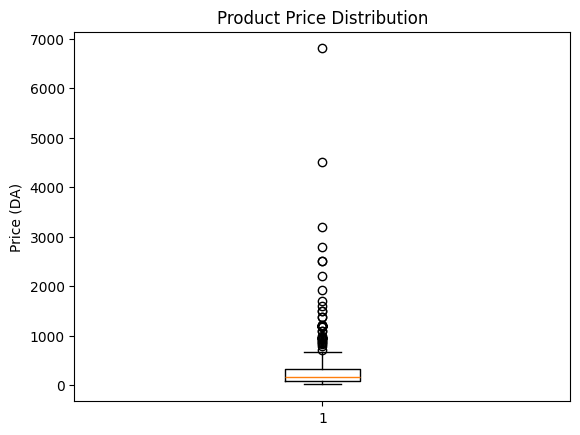

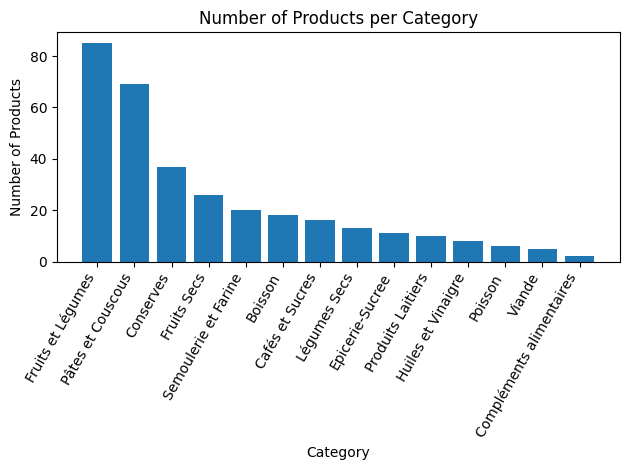

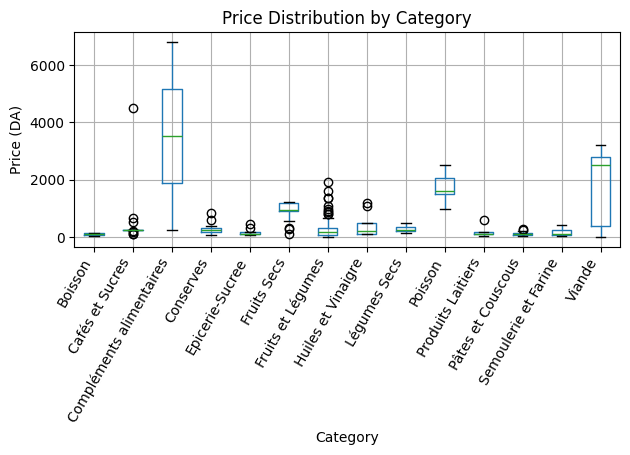

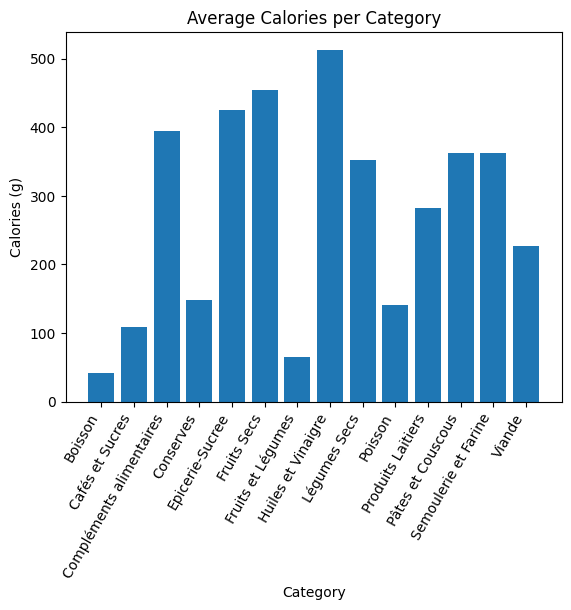

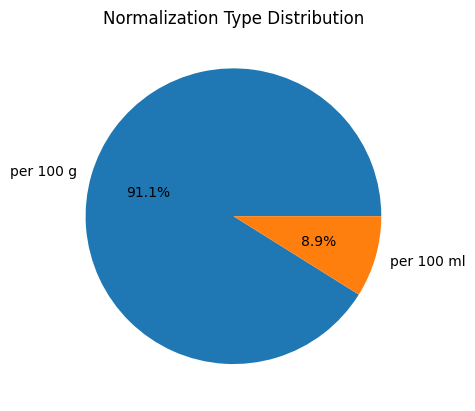

In [107]:
plt.boxplot(data["Price"])
plt.title("Product Price Distribution")
plt.ylabel("Price (DA)")
plt.show()

category_counts = data["Category"].value_counts()

plt.bar(category_counts.index, category_counts.values)

plt.title("Number of Products per Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

data.boxplot(column="Price", by="Category", rot=60)
plt.xticks(rotation=60, ha='right')
plt.title("Price Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Price (DA)")
plt.tight_layout()
plt.show()


calories_by_cat = data.groupby("Category")["Calories (g)"].mean()

plt.bar(calories_by_cat.index, calories_by_cat.values)
plt.title("Average Calories per Category")
plt.xlabel("Category")
plt.ylabel("Calories (g)")
plt.xticks(rotation=60, ha="right")
plt.show()

counts = data["Nutritional Unit"].value_counts()

plt.figure()
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
plt.title("Normalization Type Distribution")
plt.show()



# Recipes Data Construction

In [108]:
recipes_header = [
    "RID",
    "Name",
    "type", # (Breakfast, lunch, dinner)
    "Category", # (Vegitarian, Low-Carb, High-Protein etc...)
    "total_price", # calculated 
    "provided_calories" # calculated
]
recipes_data = pd.DataFrame(columns = recipes_header)

recipe_ingredient_header = [
    "PID", # from products data
    "RID", # from recipes data
    "Quantity"
]
recipe_ingredient_data = pd.DataFrame(columns = recipe_ingredient_header)

recipes_data.to_csv("data/recipes.csv", index=False, encoding="utf-8-sig")
recipe_ingredient_data.to_csv("data/recipe_ingredient.csv", index=False, encoding="utf-8-sig")

## Recipe Consolidation Workflow - PID-Based System


The recipe dataset was constructed manually following a structured PID-based approach to ensure consistency and compatibility with the main products dataset.

### Step-by-step process:

1. **Template Preparation**  
   We started by providing a standardized template to ensure all recipes follow a unified format.

2. **Recipe File Creation**  
   Each contributor copied the template into `data/recipes_input/` and renamed it using their name, then filled it with their own recipes.

3. **Product Linking via PIDs**  
   For each ingredient, we retrieved the corresponding Product ID (PID) from `data/products.csv`.  
   This allowed us to link every recipe ingredient directly to the consolidated product dataset.

4. **Quantity Specification**  
   Each PID was associated with a quantity, carefully written with units (e.g., `100 g`, `15 ml`, `2 pieces`) to maintain consistency across all recipes.

5. **Validation and Consolidation**  
   After all recipe files were completed, they were validated and then consolidated into a unified dataset using a processing cell that merges all inputs.

###  CSV Format:

```
Name,Type,Category,PIDs,Quantities
Breakfast Omelette,Breakfast,Vegetarian,"3;191;200;162;152","3;100 g;50 g;15 ml;1 g"
```

- **Name**: Recipe name
- **Type**: Breakfast, Lunch, or Dinner
- **Category**: Vegetarian, Non-Vegetarian, Vegan, etc.
- **PIDs**: Semicolon-separated product IDs (from data/products.csv)
- **Quantities**: Semicolon-separated quantities with units (e.g., "100 g", "15 ml", "3")


### Final Outcome

The result is a structured recipe dataset where every recipe is fully linked to the product database through PIDs, enabling seamless integration for further analysis, nutritional computation, and system usage.

In [109]:
from modules.recipe_consolidation import run_consolidation

# Run the consolidation process
recipes_df, recipe_ingredients_df = run_consolidation(
    products_csv="data/products.csv",
    recipes_input_dir="data/recipes_input"
)

RECIPE CONSOLIDATION PROCESS

1. Loading individual recipe files...
Found 5 recipe file(s)
   Loaded 191 recipes

2. Calculating totals for each recipe...

3. Generating output CSVs...

4. Validation Report:
   ✓ Recipes consolidated: 191
   ⚠ Warnings: 0
   ✗ Errors: 0

5. Export Complete:
   ✓ data/recipes.csv (191 recipes)
   ✓ data/recipe_ingredient.csv (835 items)


In [110]:
# View consolidated recipes
print("CONSOLIDATED RECIPES")
print(recipes_df.head(3))
print("\nRECIPE INGREDIENTS MAPPING")
print(recipe_ingredients_df.head(3))

CONSOLIDATED RECIPES
   RID                  Name       type     Category  total_price  \
0    1     Chicken Rice Bowl      Lunch  Gluten-Free        97.73   
1    2  Gluten-Free Omelette  Breakfast  Gluten-Free       487.59   
2    3       Tuna Salad Bowl      Lunch  Gluten-Free       213.99   

   provided_calories  provided_protein  provided_fat  provided_carbs  
0             987.29            241.20         71.33          649.99  
1             403.59            166.04        209.52           15.31  
2             296.81            126.53        112.32           70.29  

RECIPE INGREDIENTS MAPPING
   PID  RID Quantity
0  309    1    150 g
1   81    1    200 g
2  228    1    10 ml


In [111]:
recipes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RID                191 non-null    int64  
 1   Name               191 non-null    str    
 2   type               191 non-null    str    
 3   Category           191 non-null    str    
 4   total_price        191 non-null    float64
 5   provided_calories  191 non-null    float64
 6   provided_protein   191 non-null    float64
 7   provided_fat       191 non-null    float64
 8   provided_carbs     191 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 13.6 KB


In [112]:
recipes_df.describe()

,RID,total_price,provided_calories,provided_protein,provided_fat,provided_carbs
count,191.0000,191.000000,191.000000,191.000000,191.000000,191.000000
mean,96.0000,246.324817,657.962513,171.238377,216.747330,271.229476
std,55.2811,171.197658,405.694683,125.643538,147.144748,307.375810
min,1.0000,18.030000,115.620000,4.010000,4.500000,2.040000
25%,48.5000,93.435000,351.485000,112.480000,114.885000,28.360000
50%,96.0000,184.750000,538.400000,159.130000,176.400000,158.050000
75%,143.5000,399.220000,874.790000,205.720000,282.940000,363.780000
max,191.0000,748.500000,2142.400000,1257.200000,1170.000000,1419.120000


# Recipe data visualisation

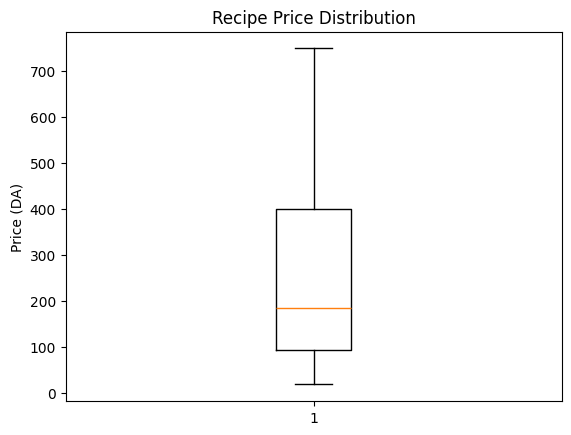

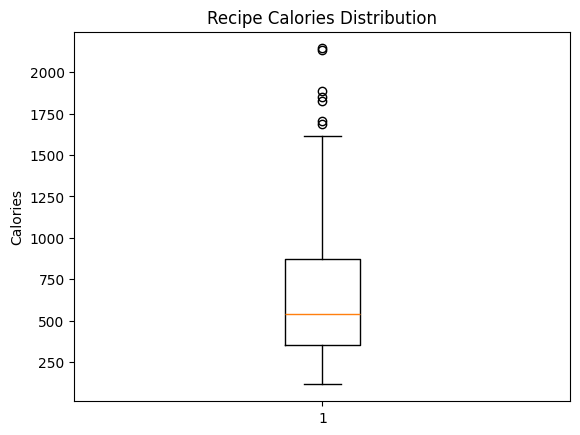

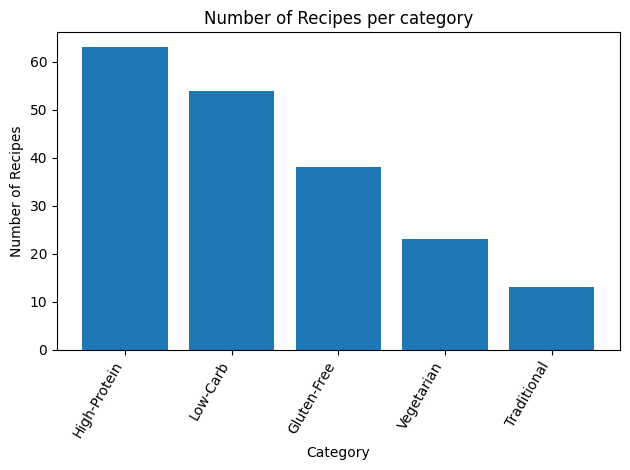

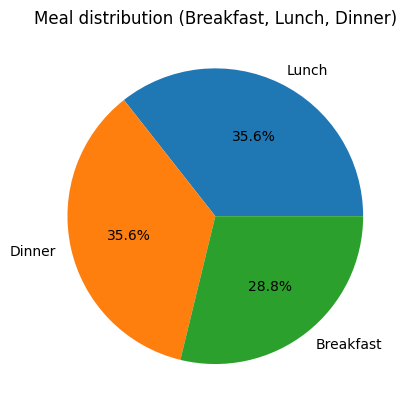

In [113]:
plt.boxplot(recipes_df["total_price"])
plt.title("Recipe Price Distribution")
plt.ylabel("Price (DA)")
plt.show()

plt.boxplot(recipes_df["provided_calories"])
plt.title("Recipe Calories Distribution")
plt.ylabel("Calories")
plt.show()

recipe_categories_count = recipes_df["Category"].value_counts()

plt.bar(recipe_categories_count.index, recipe_categories_count.values)

plt.title("Number of Recipes per category")
plt.xlabel("Category")
plt.ylabel("Number of Recipes")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()


recipe_type_counts = recipes_df["type"].value_counts()

plt.figure()
plt.pie(recipe_type_counts.values, labels=recipe_type_counts.index, autopct="%1.1f%%")
plt.title("Meal distribution (Breakfast, Lunch, Dinner)")
plt.show()



# Transition Model

Here we build our transition model by organising all colleced recipes into a datastructure designed for easy access and use across all the upcoming algorithms. the transition model is in the form of
a dictionary where the keys are the meal types (Breakfast, Lunch, Dinner). each item then is a dictionary that maps the recipe's name to a tuple containing the meal's information.

As for NUTRI_PREFERENCE_MAP, we use it to define the macronutrients distribution ratios according to the preference of the user

In [114]:
NUTRI_PREFERENCE_MAP = {
    "maintain":       {"protein": 0.30, "fat": 0.25, "carbs": 0.45},
    "gain":   {"protein": 0.40, "fat": 0.25, "carbs": 0.35},
    "loss":       {"protein": 0.25, "fat": 0.35, "carbs": 0.40},
}

def Gettransitionmodel(recipes_df):
    result = {}

    for _, row in recipes_df.iterrows():
        meal_type = row["type"]
        meal_name = row["Name"]

        meal_info = (
            row["Category"],
            row["total_price"],
            row["provided_calories"],
            row["provided_protein"],
            row["provided_carbs"],
            row["provided_fat"]
        )
        if meal_type not in result:
           result[meal_type] = {}

        result[meal_type][meal_name] = meal_info

    return result

TransitionModel = Gettransitionmodel(recipes_df)


# Genetic Algorithms

Searches for the optimal 30-day meal plan (3 meals/day) that satisfies budget, calorie, macronutrient, and variety constraints.

### GAProblem

The problem definition. On construction it pre-computes per-gram macro targets from TDEE and the chosen nutrition preference.

Key methods:


`get_total_cost`: Sums the plan's total price across all 30 days

`get_total_cal`: Sums daily calories, logging days outside the ±10% TDEE window 

`_macro_penalty_for_day`: Returns mean relative deviation from protein/fat/carb targets for a single day

`fitness_function`: Combines all penalties into a single score (higher = better)

`generate_random_state`: Produces a random 30-day plan for initial population seeding

**Fitness function** is a weighted sum of four penalties, all normalised to `[0, 1]`:

fitness = −(0.30 × cost + 0.30 × nutrition + 0.30 × macros + 0.10 × diversity)

A fitness above `−0.015` is treated as good enough to return early.

### GASearch

Standard GA loop:

1. **Initialisation**: generates 80 random plans, keeps the top 20 by fitness
2. **Evolution**: runs up to 200 generations of crossover + mutation on the surviving population
3. **Early exit**: returns immediately if any candidate exceeds the fitness threshold
4. **Fallback**: returns the best candidate found after all generations are exhausted


### Crossover

Every pair of parents in the population is crossed, making this **exhaustive pairwise crossover**. For each pair:

1. A random cut-point is chosen between days 1–28
2. Two children are produced by swapping the tails:

```
Parent A: [d1, d2, ... d_cut | d_cut+1, ... d30]
Parent B: [d1, d2, ... d_cut | d_cut+1, ... d30]

Child A:  [A's head           | B's tail         ]
Child B:  [B's head           | A's tail         ]
```

This preserves contiguous day sequences from each parent, so coherent early-week or late-week patterns can survive into the next generation.

### Mutation

After crossover, each child undergoes exactly one mutation:

- A **random day** is selected from the 30-day plan
- That day's **lunch** is replaced with a randomly sampled meal from the Lunch pool
- Breakfast and dinner on that day are left untouched

**Why only lunch?** This is a deliberate design choice — lunch tends to be the most flexible meal nutritionally and budget-wise, making it a lower-risk mutation point. Mutating breakfast or dinner simultaneously with a crossover would introduce too much disruption per generation, slowing convergence.


In [115]:

# helper functions
def resolve_nutri_preference(preference_str):
    key = preference_str.strip().lower()
    if key not in NUTRI_PREFERENCE_MAP:
        valid = ", ".join(NUTRI_PREFERENCE_MAP.keys())
        raise ValueError(f"Unknown preference '{preference_str}'. Valid options: {valid}")
    return NUTRI_PREFERENCE_MAP[key]
def diversity_penalty_per_week(state):
    penalty = 0
    days_per_week = 7
    meals_per_day = 3

    for start in range(0, len(state), days_per_week):
        week = state[start:start + days_per_week]

        week_meals = [meal for day in week for meal in day]

        counts = {}
        for meal in week_meals:
            counts[meal] = counts.get(meal, 0) + 1

        for meal, count in counts.items():
            if count > 2:
                penalty += (count - 2)
    return penalty / (len(state) * meals_per_day)

def crossover_and_mutation(population,problem):
    childs = []
    model = problem.transitionmodel
    for i in range(len(population)):
        for j in range(i+1,len(population)):
            cutoff = random.randrange(1,29)
            parent_a = population[i][0]
            parent_b = population[j][0]
            child_a = parent_a[:cutoff] + parent_b[cutoff:]
            child_b = parent_b[:cutoff] + parent_a[cutoff:]
            random_lunch_a = random.choice(list(model['Lunch'].keys()))
            random_lunch_b = random.choice(list(model['Lunch'].keys()))
            random_pos_a  = random.randrange(30)
            random_pos_b  = random.randrange(30)
            t1 =   [child_a[random_pos_a][0],random_lunch_a, child_a[random_pos_a][2]]
            t2 =  [child_b[random_pos_b][0],random_lunch_b, child_b[random_pos_b][2]]
            child_a[random_pos_a] = tuple(t1) 
            child_b[random_pos_b] = tuple(t2) 
            childs.append((child_a,problem.fitness_function(child_a)))
            childs.append((child_b,problem.fitness_function(child_b)))
    return childs
# GA problem definition
class GAProblem:
    def __init__(self, recipes_df, total_price, tdee, nutri_preference_str="maintain"):
        self.size = 90 # we did not use this at all occurance = 1
        self.total_price = total_price
        self.tdee = tdee
        self.transitionmodel = TransitionModel
        prefs = resolve_nutri_preference(nutri_preference_str)
        self.target_protein_g = tdee * prefs["protein"]
        self.target_fat_g     = tdee * prefs["fat"]
        self.target_carbs_g   = tdee * prefs["carbs"]
     
    def get_total_cost(self, state):
        total_cost = 0
        model = self.transitionmodel
        for day in state:
           total_cost += (
               model["Breakfast"][day[0]][1] +
               model["Lunch"][day[1]][1] +
               model["Dinner"][day[2]][1]
           )
        return total_cost
    
    
    def get_total_cal(self,state):
        day_calories = []
        model = self.transitionmodel
        tdee = self.tdee
        for day in state:
            day_cal = (
            model["Breakfast"][day[0]][2] +
            model["Lunch"][day[1]][2] +
            model["Dinner"][day[2]][2]
        )
            if day_cal > tdee * 1.1 or day_cal < tdee * 0.9:
                print(day_cal)
                print("Out of calories range")
            day_calories.append(day_cal)
        
        return sum(day_calories)
    

    def _macro_penalty_for_day(self, day):
        model = self.transitionmodel
        target_fat = self.target_fat_g
        target_protein = self.target_protein_g
        target_carbs = self.target_carbs_g
        actual_protein =  model["Breakfast"][day[0]][3] +  model["Dinner"][day[2]][3] +  model["Lunch"][day[1]][3]
        actual_carbs   = model["Breakfast"][day[0]][4] +  model["Dinner"][day[2]][4] +  model["Lunch"][day[1]][4]
        actual_fat   = model["Breakfast"][day[0]][5] +  model["Dinner"][day[2]][5] +  model["Lunch"][day[1]][5]  
        protein_dev = abs(actual_protein - target_protein) / target_protein
        fat_dev     = abs(actual_fat     - target_fat)     / target_fat
        carbs_dev   = abs(actual_carbs   - target_carbs)   / target_carbs
        return (protein_dev + fat_dev + carbs_dev) / 3
    

    def fitness_function(self, state):
        total_cost = self.get_total_cost(state)
        total_price = self.total_price
        cost_penalty = 0.5 + min((total_cost - total_price) / (total_cost), 0.5) if (total_price - total_cost) / (total_price) < 0 else (total_price - total_cost) / (total_price)
        tdee = self.tdee
        lower_bound = 0.9 * tdee
        upper_bound = 1.1 * tdee

        bad_days = 0
        total_macro_dev=0
        model = self.transitionmodel
        for day in state:
            day_calories = (
                model["Breakfast"][day[0]][2] +
                model["Lunch"][day[1]][2] +
                model["Dinner"][day[2]][2]
            )
            if day_calories < lower_bound or day_calories > upper_bound:
                bad_days += (0.8 + min(0.2, abs(tdee-day_calories) / tdee))
            else:
                bad_days += abs(tdee-day_calories) / tdee
            total_macro_dev += self._macro_penalty_for_day(day)
        nutrition_penalty = bad_days / len(state)
        macro_penalty     = total_macro_dev / len(state)
        diversity_penalty = diversity_penalty_per_week(state)
        fitness = -(
            0.30 * cost_penalty +
            0.30* nutrition_penalty +
            0.1 * diversity_penalty +
            0.30* macro_penalty
        )
        return fitness
    
    
    def generate_random_state(self):
         model = self.transitionmodel
         breakfast_list = list(model['Breakfast'].keys())
         lunch_list = list(model['Lunch'].keys())
         dinner_list = list(model['Dinner'].keys())
         return [(random.choice(breakfast_list),
                  random.choice(lunch_list),
                  random.choice(dinner_list))
                    for _ in range(30)]
# GA Search
def GASearch(problem):
    # step 1 Selection:
    list_of_states = []
    for _ in range(80):
        state = problem.generate_random_state()
        fitness = problem.fitness_function(state)
        list_of_states.append((state,fitness))
    population = sorted(list_of_states, key=lambda x: x[1], reverse=True)[:20]
    # step 2 and 3 crossover and mutation
    for _ in range(200):
        population = sorted(population, key=lambda x: x[1], reverse=True)[:20]
        for state, fitness in population:
            if fitness > -0.015:
                return (state, fitness)
        population =  crossover_and_mutation(population,problem)
    best_candidate = sorted(population, key=lambda x: x[1], reverse=True)[:1]
    return best_candidate[0]

# GA Test

In [116]:
g = GAProblem(recipes_df,22000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(g.get_total_cost(solution))
print(g.get_total_cal(solution))

[('Beet Yogurt Breakfast Plate', 'Chicken Wrap', 'Chickpea Spinach Rice'), ('Fruit Salad', 'Chicken Hummus Plate', 'Tlitli Beef'), ('Pomegranate Yogurt Crunch', 'Garlic Shrimp Bowl', 'Rechta'), ('Rice Porridge', 'Kefta', 'Merlan Lemon Olive Plate'), ('Oat Banana Pancake Bowl', 'Spaghetti Bolognese', 'Shrimp Broccoli Plate'), ('Potato Omelette', 'Egg Fried Rice', 'Spinach Chicken Plate'), ('Beet Yogurt Breakfast Plate', 'Chicken Black Bean Bowl', 'Lamb with Olive and Tomato'), ('Beet Carrot Salad', 'Chicken Harissa Rice Bowl', 'Beef with Chickpea'), ('Banana Protein Smoothie', 'Tuna Chickpea Mint Salad', 'Tlitli Beef'), ('Protein Smooth Bowl', 'Beef Lettuce Bowl', 'Beef Rice Bowl'), ('Chocolat Milk', 'Chicken Spinach Rice', 'Chicken Mchermel'), ('Yogurt with Honey', 'Tuna and Lettuce salade', 'Vegetable Soup'), ('Bananas and Almond Bowl', 'Chicken Black Bean Bowl', 'Turkey Zucchini Stir Fry'), ('Tomato and Pepper Omelette', 'Loubia Chicken Plate', 'Rice with Chicken and Green Bean'), ('

# GA Visualizations

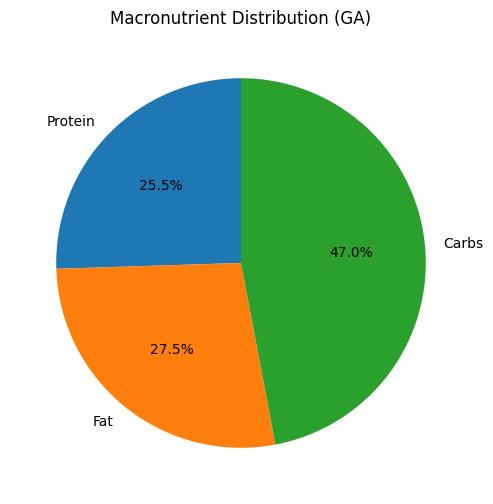

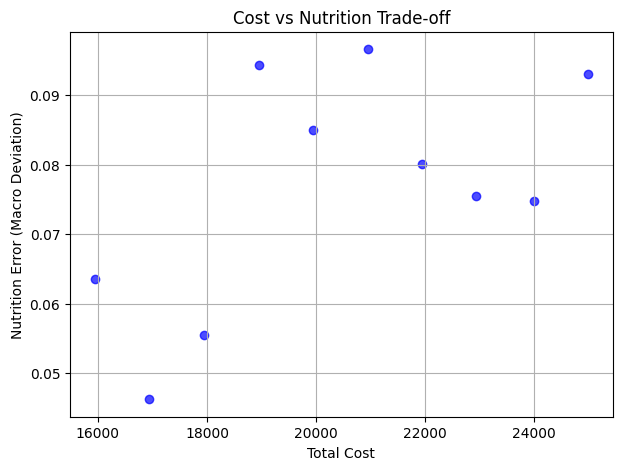

In [117]:

def get_macro_nutrition(transitionmodel, state): # we have two of this one for visulaization and one for the fitness 
    protein_v = 0
    fat_v = 0
    carbs_v = 0
    total_cal = 0
    for day in state:
        total_cal += transitionmodel["Breakfast"][day[0]][2] + transitionmodel["Lunch"][day[1]][2] + transitionmodel["Dinner"][day[2]][2]
        protein_v += transitionmodel["Breakfast"][day[0]][3] + transitionmodel["Lunch"][day[1]][3] + transitionmodel["Dinner"][day[2]][3]
        fat_v     +=transitionmodel["Breakfast"][day[0]][5] + transitionmodel["Lunch"][day[1]][5] + transitionmodel["Dinner"][day[2]][5]
        carbs_v   += transitionmodel["Breakfast"][day[0]][4] + transitionmodel["Lunch"][day[1]][4] + transitionmodel["Dinner"][day[2]][4]
    return [protein_v / total_cal, fat_v / total_cal, carbs_v / total_cal]

def macro_error(meals,state): # we have two also in this we use it in the visualization,fitness,greedy,A*
    macros = get_macro_nutrition(meals,state)

    target = [0.3, 0.25, 0.45]  # example , we can take it from the problem formulation

    error = sum(abs(macros[i] - target[i]) for i in range(3))

    return error

def get_axis_plot(meals):
     costs = []
     errors = []
     i = 16000
     for _ in range(10):  # 30 different solution
        g = GAProblem(recipes_df,i,2000)
        solution,_ = GASearch(g)
        cost = g.get_total_cost(solution)
        error = macro_error(meals,solution)
        i += 1000 
        costs.append(cost)
        errors.append(error)
     return costs,errors

meals_details = TransitionModel # we caluclate for each prblem except the CSP
labels = ['Protein', 'Fat', 'Carbs']
values = get_macro_nutrition(meals_details,solution)
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Macronutrient Distribution (GA)')
plt.show()
x_axis,y_axis = get_axis_plot(meals_details)
plt.figure(figsize=(7,5))
plt.scatter(x_axis, y_axis, color='blue', alpha=0.7)
plt.xlabel("Total Cost")
plt.ylabel("Nutrition Error (Macro Deviation)")
plt.title("Cost vs Nutrition Trade-off")
plt.grid(True)
plt.show()


# A* and Greedy

## State & Node Representations

### MealPlannerState

A state of the plan at a single meal slot. Tracks:

- **Position**: which day and meal type (Breakfast / Lunch / Dinner)
- **Selected meal**: the chosen recipe for this slot
- **Running totals**: remaining budget, and today's consumed calories, protein, carbs, and fat
- **used_meals**: set for diversity tracking across the plan

Equality and hashing are intentionally scoped to `(day, meal_type, meal)` only. two states at the same position with the same meal are considered identical regardless of budget or nutrition totals. This keeps the visited-state check efficient and avoids revisiting the same meal choice for a given slot.

### Node

A search tree wrapper around a state, used by graph search algorithms

`g`: Accumulated path cost from the root
`f`: `g + heuristic` the evaluation function
`depth` Distance from the root node
`parent` / `action` Backtracking links for path reconstruction

**`path()`** walks back up the parent chain and returns the sequence of actions from root to this node, which reconstructs the chosen meal sequence.

Ordering (`__lt__`) is defined on `f`, so nodes can be pushed directly into a priority queue.

In [49]:
class MealPlannerState:
    def __init__(self, day_number, meal_type, meal, remaining_budget, today_calorie_use, today_protein_use, today_carbs_use, today_fat_use, used_meals = None):
        self.day = day_number
        self.meal_type = meal_type
        self.meal = meal
        self.remaining_budget = remaining_budget
        self.today_calorie_use = today_calorie_use
        self.today_protein_use = today_protein_use
        self.today_carbs_use = today_carbs_use
        self.today_fat_use = today_fat_use
        self.used_meals = used_meals
        
    def __eq__(self, other):
        return isinstance(other, MealPlannerState) and \
            self.day == other.day and \
            self.meal_type == other.meal_type and \
            self.meal == other.meal

    def __hash__(self):
        return hash((self.day, self.meal_type, self.meal))

class Node:    
    def __init__(self, state, parent=None, action=None, cost=0, heuristic=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.g = (parent.g + cost) if parent else 0
        self.f = self.g + heuristic
        self.depth = 0 if parent is None else parent.depth + 1

    def path(self):
        node = self
        actions = []
        while node.parent is not None:
            actions.append(node.action)
            node = node.parent
        actions.reverse()
        return actions

    def __lt__(self, other):
        return self.f < other.f

    def __eq__(self, other):
        return isinstance(other, Node) and self.state == other.state

    def __hash__(self):
        return hash(self.state)


# Problem Class

## Meal Planning Problem

Defines the search problem used by graph-search algorithms. Each call to `expand_node` moves one meal slot forward, building a 3-meals-per-day plan over `num_days`.

### Setup

The problem is initialised with a TDEE, total budget, number of days, and a macro preference. Meal types are assigned fixed **calorie and budget weights** reflecting typical meal proportions:

Breakfast: 25% || Lunch: 40% || Dinner: 35%

The **initial state** starts at day 0, meal slot 0, with full budget and zero nutritional totals.

### is_goal

A node is a goal if:
- All `num_days × 3` slots are filled
- Total cost is within budget
- Total calories are within ±10% of `TDEE × num_days`.

### expand_node

At each slot, every available meal of the correct type is considered as an action. A meal is skipped if it appears in `used_meals` (diversity enforcement). Every 15 days the used-meals set resets, allowing repetition across longer plans. This ensures variety, where every meal appears exactly once every 2 weeks.

For each valid meal a new state is produced, advancing the slot index and updating budget and daily nutritional running totals. Daily totals reset when a new day begins.

### calculate_cost

The cost of choosing a meal is the **mean normalised deviation** across five parameters: price, calories, protein, carbs, and fat. each measured against that meal type's fair share of the day's budget and TDEE:

```
cost = mean(|actual − allocated| / allocated)  for each {price, cal, protein, carbs, fat}
```

A meal that perfectly hits its allocated share costs 0 (theoritical, impossible in practice) larger deviations increase cost.

### calculate_heuristic

Estimates remaining cost from the current state as the **mean relative gap** between today's running nutritional totals and the targets.

In [50]:
class MealPlanningProblem:

    def __init__(self, transition_model, TDEE, total_budget, num_days=7, macroNutri_preference="maintain"):
        self.transition_model = transition_model
        self.total_budget = total_budget
        self.TDEE = TDEE
        self.num_days = num_days
        self.meals_per_day = 3  # Breakfast, Lunch, Dinner
        self.total_slots = num_days * self.meals_per_day
        self.meal_types = ['Breakfast', 'Lunch', 'Dinner']

        self.meal_type_weights = {
            'Breakfast': 0.25,
            'Lunch': 0.40,
            'Dinner': 0.35
        }

        self.consider_deviation = True

        self.macro_nutrients_ratios = NUTRI_PREFERENCE_MAP[macroNutri_preference]

        self.initial_state = MealPlannerState(0, 0, None, total_budget, 0, 0, 0, 0, set())
        
    def _get_remaining_days(self, state):
        current_slot = state.day * self.meals_per_day + state.meal_type + 1
        remaining_slots = self.total_slots - current_slot
        return math.ceil(remaining_slots / self.meals_per_day)

    def _calculate_totals(self, recipes_list):
        total_cost = 0
        total_calories = 0
        
        i = 0
        for meal_name in recipes_list:
            recipe = self.transition_model[self.meal_types[i]][meal_name]
            total_cost += recipe[1]
            total_calories += recipe[2]
            
            i = (i+1)%3

        return total_cost, total_calories

    def is_goal(self, node):
        state = node.state
        
        if state.day < self.num_days:
            return False
        
        recipes_chosen = node.path()
        
        if len(recipes_chosen) != self.total_slots:
            return False
        
        total_cost, total_calories = self._calculate_totals(recipes_chosen)
        
        goal_calories = self.TDEE * self.num_days
        calorie_tolerance = goal_calories * 0.1
        calories_ok = abs(total_calories - goal_calories) <= calorie_tolerance or not self.consider_deviation
        
        budget_ok = total_cost <= self.total_budget
        
        return calories_ok and budget_ok

    def expand_node(self, node, use_cost=True, use_heuristic=False):
        state = node.state
        
        if state.day >= self.num_days:
            return []
        
        children = []
        valid_actions = self.transition_model[self.meal_types[node.state.meal_type]]
        
        for meal_name in valid_actions:

            if meal_name in state.used_meals:
                continue

            recipe = self.transition_model[self.meal_types[node.depth%3]][meal_name]
            
            action_cost = self.calculate_cost(node.state, meal_name) if use_cost else 0
            
            new_meal_idx = (state.meal_type + 1) % self.meals_per_day
            new_day = state.day if new_meal_idx > 0 else state.day + 1
            new_remaining_budget = state.remaining_budget - recipe[1]
            new_calorie_use = 0 if new_meal_idx == 0 else state.today_calorie_use + recipe[2]
            new_protein_use = 0 if new_meal_idx == 0 else state.today_protein_use + recipe[3]
            new_carbs_use = 0 if new_meal_idx == 0 else state.today_carbs_use + recipe[4]
            new_fat_use = 0 if new_meal_idx == 0 else state.today_fat_use + recipe[5]
            
            if new_day % 15 == 0 and new_day != 0:
                new_used_meals = set({})
            else:
                new_used_meals = set(state.used_meals)

            new_used_meals.add(meal_name)
            
            new_state = MealPlannerState(new_day, new_meal_idx, meal_name, new_remaining_budget,
            new_calorie_use, new_protein_use, new_carbs_use, new_fat_use, new_used_meals)
            
            heuristic = self.calculate_heuristic(new_state) if use_heuristic else 0
            
            child = Node(new_state, parent=node, action=meal_name, cost=action_cost, heuristic=heuristic)
            children.append(child)
        
        return children

    def calculate_cost(self, state, meal_name=None):
        if meal_name is None:
            meal_name = state.meal
        
        if meal_name is None:
            return 0
        
        recipe = self.transition_model[self.meal_types[state.meal_type]][meal_name]
        meal_type = self.meal_types[state.meal_type]
        
        remaining_days = self._get_remaining_days(state)
        
        allocated_price = self.meal_type_weights[meal_type] * (state.remaining_budget / max(1, remaining_days))
        allocated_calories = self.meal_type_weights[meal_type] * self.TDEE 

        allocated_protein = self.meal_type_weights[meal_type] * self.TDEE * self.macro_nutrients_ratios["protein"]
        allocated_carbs = self.meal_type_weights[meal_type] * self.TDEE * self.macro_nutrients_ratios["carbs"]
        allocated_fat = self.meal_type_weights[meal_type] * self.TDEE * self.macro_nutrients_ratios["fat"]

        price_deviation = abs(recipe[1] - allocated_price)
        calorie_deviation = abs(recipe[2] - allocated_calories)
        protein_deviation = abs(recipe[3] - allocated_protein)
        carbs_deviation = abs(recipe[4] - allocated_carbs)
        fat_deviation = abs(recipe[5] - allocated_fat)

        normalized_price_dev = price_deviation / allocated_price if allocated_price > 0 else 0
        normalized_cal_dev = calorie_deviation / allocated_calories if allocated_calories > 0 else 0
        normalized_protein_dev = protein_deviation / allocated_protein if allocated_protein > 0 else 0
        normalized_carbs_dev = carbs_deviation / allocated_carbs if allocated_carbs > 0 else 0
        normalized_fat_dev = fat_deviation / allocated_fat if allocated_fat > 0 else 0

        total_cost = (normalized_price_dev + normalized_cal_dev + normalized_protein_dev + normalized_carbs_dev + normalized_fat_dev) / 5.0
        
        return total_cost


    def calculate_heuristic(self, state):
        remaining_slots = self.total_slots - (state.day * self.meals_per_day + state.meal_type)
        if remaining_slots <= 0:
            return 0

        calorie_gap = abs(state.today_calorie_use - self.TDEE) / self.TDEE
        protein_gap = abs(state.today_protein_use - (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["protein"])) / (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["protein"]) if (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["protein"]) > 0 else 0
        carbs_gap = abs(state.today_carbs_use - (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["carbs"])) / (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["carbs"]) if (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["carbs"]) > 0 else 0
        fat_gap = abs(state.today_fat_use - (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["fat"])) / (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["fat"]) if (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["fat"]) > 0 else 0

        return (calorie_gap + protein_gap + carbs_gap + fat_gap) / 4.0


# Search Class

Both algorithms share the same structure: a priority queue frontier, an explored set for cycle detection, and the same solution extraction logic. The only differences are how nodes are evaluated and how strictly the goal is checked.

### Evaluation Function

| Algorithm | `f(n)` | `consider_deviation` |
|---|---|---|
| A\* | `g(n) + h(n)` cost so far plus heuristic estimate | `True` goal requires calories within ±10% of TDEE |
| Greedy | `h(n)` heuristic only | `False` goal only checks budget and slot count |

A\* trades speed for solution quality: the accumulated cost `g(n)` steers it away from nutritionally poor choices made earlier in the plan. Greedy ignores past cost and expands whichever node looks closest to the goal right now, making it faster but less precise.

### Search Loop

1. Push the initial state onto the frontier
2. Pop the lowest-`f` node
3. Return if it satisfies the goal
4. Expand its children skipping any already explored or already queued
5. Repeat until a solution is found or the frontier is exhausted

### _get_solution_path

`node.path()` returns the flat action sequence `[B, L, D, B, L, D, ...]`. This is re-grouped into a list of `(Breakfast, Lunch, Dinner)` tuples, one per day, matching the format used by the rest of the system.

### A*

In [51]:
import queue

class AstarSearch:
    def __init__(self,problem):
        self.problem = problem
        self.problem.consider_deviation = True
        self.frontier = queue.PriorityQueue()

        self.explored = set()

    def search(self):

        node = Node(self.problem.initial_state)
        self.frontier.put(node)
        
        while True:
            if self.frontier.empty():
                return None

            node = self.frontier.get()
            
            if self.problem.is_goal(node):
                solution = self._get_solution_path(node)
                return solution

            self.explored.add(node.state)

            children = self.problem.expand_node(node, True, True)

            for child in children:
                if child.state not in self.explored and child not in self.frontier.queue:
                    self.frontier.put(child)

    def _get_solution_path(self, solution_node):
        path = solution_node.path()
        path = [tuple([
                path[i],
                path[i+1],
                path[i+2]
            ]) for i in range(0, len(path), 3)]

        return path


### Greedy

In [52]:
class GreedySearch:
    def __init__(self,problem):
        self.problem = problem
        self.problem.consider_deviation = False
        self.frontier = queue.PriorityQueue()

        self.explored = set()

    def search(self):

        node = Node(self.problem.initial_state)
        self.frontier.put(node)
        
        while True:
            if self.frontier.empty():
                return None

            node = self.frontier.get()
            
            if self.problem.is_goal(node):
                solution = self._get_solution_path(node)
                return solution

            self.explored.add(node.state)

            children = self.problem.expand_node(node, False, True)

            for child in children:
                if child.state not in self.explored and child not in self.frontier.queue:
                    self.frontier.put(child)

    def _get_solution_path(self, solution_node):
        path = solution_node.path()
        path = [tuple([
                path[i],
                path[i+1],
                path[i+2]
            ]) for i in range(0, len(path), 3)]

        return path

# Run Test

In [53]:
def get_solution_nutrition(solution, TransitionModel):
    total_cost = 0
    total_calories = 0

    for day_meals in solution:
        breakfast, lunch, dinner = day_meals
        for slot, meal in zip(["Breakfast", "Lunch", "Dinner"], [breakfast, lunch, dinner]):
            info = TransitionModel[slot][meal]
            # info = (Category, cost, kcal, protein, carbs, fat)
            total_cost     += info[1]
            total_calories += info[2]

    return total_cost, total_calories

def run_and_collect(TDEE, budget, days, strat):
    problem = MealPlanningProblem(TransitionModel, TDEE, budget, days)
    S = AstarSearch(problem) if strat == "A*" else GreedySearch(problem)
    solution = S.search()
    if solution is None:
        return None
    cost, cal = get_solution_nutrition(solution, TransitionModel)
    return solution, cost, cal

print("A* Result: ")
Astar_Sol, cost, cal = run_and_collect(2600, 7000, 7, "A*")

print(Astar_Sol)
print(f"Cost: {cost}")
print(f"Calories: {cal}")

print("\n\nGreedy search Result: ")
Greedy_Sol, cost, cal = run_and_collect(2600, 25000, 30, "Greedy")

print(Greedy_Sol)
print(f"Cost: {cost}")
print(f"Calories: {cal}")

A* Result: 
[('Egg Oat Protein Pancakes', 'Tuna Chickpea Mint Salad', 'Chicken Mchermel'), ('Protein peanaut butter Smoothie', 'Shrimp Rice Coriander Bowl', 'Tlitli Beef'), ('Oat Banana Pancake Bowl', 'Shrimp Green Bean Rice', 'Chorba Lentil Lamb'), ('Strawberry Banana Smoothie', 'Tajine Zitoun', 'Beef Loubia Stew'), ('Lentil and Egg', 'Taco Spaghetti', 'Chorba Vermicelle Beef'), ('Chickpea Egg Garlic Bowl', 'Tuna Rice Olive Bowl', 'Beef Mushroom Pasta'), ('Egg White Veggie Wrap', 'Sardine Chickpea Tomato Bowl', 'Chickpea Spinach Rice')]
Cost: 6686.630000000001
Calories: 16408.059999999998


Greedy search Result: 
[('Egg Oat Protein Pancakes', 'Merlan with Green Bean Plate', 'Chicken Veg Stir Fry'), ('Oat Banana Pancake Bowl', 'Shrimp and Hmiss', 'Merlan with Spinach and Tomato'), ('Protein peanaut butter Smoothie', 'Lentil Soup', 'Flafla'), ('Coffee with Chocolat Biscuits', 'Garlic Shrimp Bowl', 'Merlan Lemon Olive Plate'), ('Strawberry Banana Smoothie', 'Tuna Salad Bowl', 'Chorba Ver

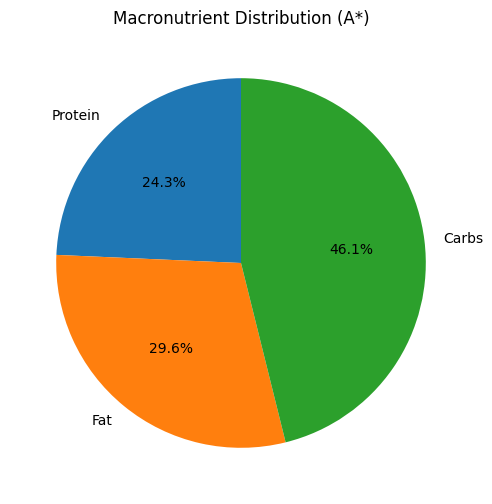

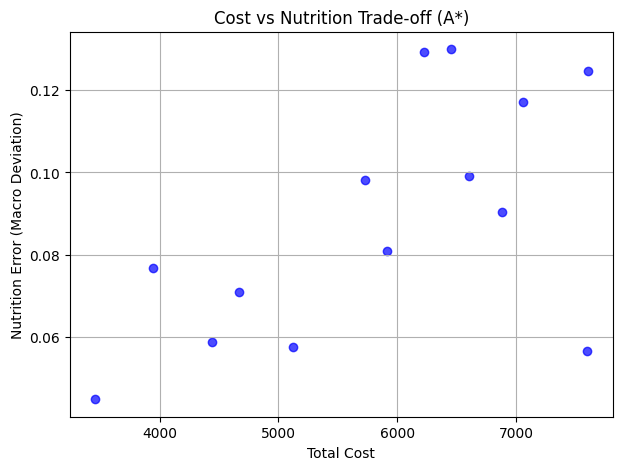

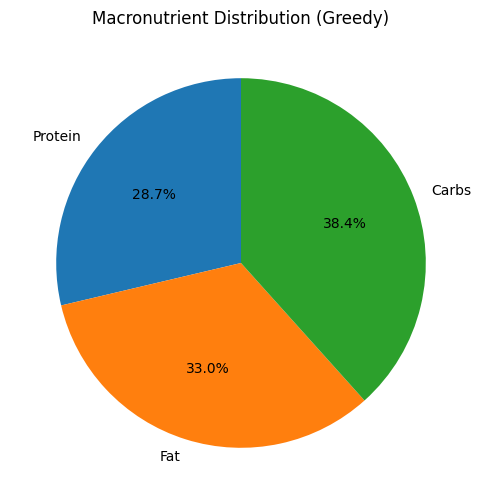

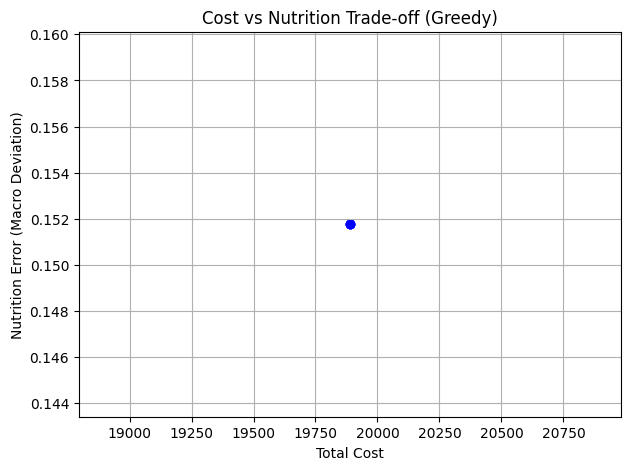

In [54]:


meals_details = TransitionModel # we caluclate for each prblem except the CSP
labels = ['Protein', 'Fat', 'Carbs']
Astar_values = get_macro_nutrition(meals_details, Astar_Sol) 
Greedy_values = get_macro_nutrition(meals_details, Greedy_Sol)

plt.figure(figsize=(6,6))
plt.pie(Astar_values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Macronutrient Distribution (A*)')
plt.show()

def Astar_axis_plot(meals):
     costs = []
     errors = []
     budgets = range(3500, 10001, 500)
     for b in budgets:
        solution, cost, _ = run_and_collect(2200, b, 7, "A*")
        error = macro_error(meals, solution)
        costs.append(cost)
        errors.append(error)
     return costs,errors

x_axis,y_axis = Astar_axis_plot(meals_details)
plt.figure(figsize=(7,5))
plt.scatter(x_axis, y_axis, color='blue', alpha=0.7)
plt.xlabel("Total Cost")
plt.ylabel("Nutrition Error (Macro Deviation)")
plt.title("Cost vs Nutrition Trade-off (A*)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.pie(Greedy_values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Macronutrient Distribution (Greedy)')
plt.show()


def Greedy_axis_plot(meals):
     costs = []
     errors = []
     budgets = range(25000, 30001, 1000)
     for b in budgets:
        solution, cost, _ = run_and_collect(2200, b, 30, "Greedy")
        error = macro_error(meals, solution)
        costs.append(cost)
        errors.append(error)
     return costs,errors

x_axis,y_axis = Greedy_axis_plot(meals_details)
plt.figure(figsize=(7,5))
plt.scatter(x_axis, y_axis, color='blue', alpha=0.7)
plt.xlabel("Total Cost")
plt.ylabel("Nutrition Error (Macro Deviation)")
plt.title("Cost vs Nutrition Trade-off (Greedy)")
plt.grid(True)
plt.show()


In [55]:
def variety_score(plan):
    repitions = 0
    for start in range(0, len(plan), 7):
        week = plan[start:start + 7]

        week_meals = [meal for day in week for meal in day]

        counts = {}
        for meal in week_meals:
            counts[meal] = counts.get(meal, 0) + 1

        for meal, count in counts.items():
               repitions += max(0,count-2)
    return 1-(repitions/90)
        
        
                  

ga_solutions = set()
greedy_solutions = set()
Astar_solutions = set()
price_genetic = 18000
price_greedy = 25000
tdee = 2000
for _ in range(15):
    ga_problem = GAProblem(recipes_df,price_genetic,2000)
    ga_solution, _  = GASearch(ga_problem)
    ga_solutions.add(variety_score(ga_solution))
    Greedy_problem = MealPlanningProblem(TransitionModel,2000,price_greedy/4,7)
    S = GreedySearch(Greedy_problem)
    greedy_solution = S.search()
    if greedy_solution != None:
        greedy_solutions.add(variety_score(greedy_solution))

    price_genetic += 1000
    price_greedy += 1000
    tdee += 50

print("Comparaison between the variety score of Genetic and Greedy Alogrithm solutions for 30 days:")
print(f"the max variety score provided by the Genetic Algorithm : {max(ga_solutions)}")
print(f"the min variety score provided by the Genetic Algorithm : {min(ga_solutions)}")
print(f"the average variety score provided by the Genetic Algorithm : {sum(ga_solutions)/len(ga_solutions)}")
print(f"the max variety score provided by the Greedy Algorithm : {max(greedy_solutions)}")
print(f"the min variety score provided by the Greedy Algorithm : {min(greedy_solutions)}")
print(f"the average variety score provided by the Greedy Algorithm : {sum(greedy_solutions)/len(greedy_solutions)}")


Comparaison between the variety score of Genetic and Greedy Alogrithm solutions for 30 days:
the max variety score provided by the Genetic Algorithm : 1.0
the min variety score provided by the Genetic Algorithm : 0.9888888888888889
the average variety score provided by the Genetic Algorithm : 0.9944444444444445
the max variety score provided by the Greedy Algorithm : 1.0
the min variety score provided by the Greedy Algorithm : 1.0
the average variety score provided by the Greedy Algorithm : 1.0


# CSP

Models the meal planning problem as a Constraint Satisfaction Problem. Each `(day, slot)` pair is a variable whose domain is pruned before any search begins, making backtracking significantly cheaper.

### build_domains

Each slot gets a hard cap on calories and budget (as a share of the daily budget). Meals that go above the cap are removed from the domain, immediately discarding nutritionally or financially infeasible options.

### ac3

Runs **AC-3** (Arc Consistency 3) across all pairs of meal slots within each day. For a pair `(slot_i, slot_j)`, a meal in `slot_i`'s domain is removed if no meal in `slot_j`'s domain could combine with it and still leave the third slot able to close the day within the ±10% calorie window and daily budget.

Compatibility is checked via `are_compatible`, which uses the min/max calorie and minimum cost of the third slot's remaining domain to bound what the third meal would need to contribute.

If any domain is reduced, affected arcs are re-queued. Returns `False` early if any domain empties, signalling the problem is unsolvable.

### backtrack_day

Assigns meals slot-by-slot (Breakfast → Lunch → Dinner) for a single day. Candidates are **shuffled** before iteration to introduce variety across runs. A branch is pruned immediately if adding a meal would exceed the daily budget or calorie ceiling. A complete assignment is accepted only if total calories fall within ±10% of TDEE and total cost stays within budget.

### solve

Ties everything together:

1. Build domains
2. Run AC-3 to prune, return `None` if unsolvable
3. For each day, run `backtrack_day` on the pruned domain
4. Return the full 30-day plan as a list of `(Breakfast, Lunch, Dinner)` tuples

In [56]:

class CSPproblem:
    def __init__(self, tdee, budget, transition_model, days=30, goal="maintain"):
        self.tdee = tdee
        self.daily_budget = budget / days
        self.model = transition_model
        self.days = days
        self.goal = goal
        self.slots = ["Breakfast", "Lunch", "Dinner"]

    def compute_macro_delta(self, day_meal_names):
        """Logic exactly as provided by user."""
        ratios = NUTRI_PREFERENCE_MAP[self.goal]

        actual_protein = sum(self.model[self.slots[i]][day_meal_names[i]][3] for i in range(3))
        actual_carbs   = sum(self.model[self.slots[i]][day_meal_names[i]][4] for i in range(3))
        actual_fat     = sum(self.model[self.slots[i]][day_meal_names[i]][5] for i in range(3))

        target_protein_g = (self.tdee * ratios["protein"]) / 4
        target_carbs_g   = (self.tdee * ratios["carbs"])   / 4
        target_fat_g     = (self.tdee * ratios["fat"])     / 9

        delta_protein = actual_protein - target_protein_g
        delta_carbs   = actual_carbs   - target_carbs_g
        delta_fat     = actual_fat     - target_fat_g

        penalty = (
            abs(delta_protein) / target_protein_g +
            abs(delta_carbs)   / target_carbs_g   +
            abs(delta_fat)     / target_fat_g
        ) / 3

        return {
            "actual": {"protein_g": actual_protein, "carbs_g": actual_carbs, "fat_g": actual_fat},
            "target": {"protein_g": target_protein_g, "carbs_g": target_carbs_g, "fat_g": target_fat_g},
            "delta":  {"protein_g": delta_protein,  "carbs_g": delta_carbs,  "fat_g": delta_fat},
            "penalty": min(penalty, 1.0)
        }

    def build_domains(self):
        """Logic exactly as provided by user."""
        slot_calorie_share = {"Breakfast": 0.35, "Lunch": 0.40, "Dinner": 0.40}
        slot_budget_share  = {"Breakfast": 0.35, "Lunch": 0.40, "Dinner": 0.40}

        domains = {}
        for day in range(self.days):
            for slot in self.slots:
                cal_cap    = self.tdee         * slot_calorie_share[slot]
                budget_cap = self.daily_budget * slot_budget_share[slot]

                domains[(day, slot)] = [
                    meal_name
                    for meal_name, info in self.model[slot].items()
                    if info[2] <= cal_cap 
                    and info[1] <= budget_cap 
                ]
        return domains

    def are_compatible(self, slot_i, meal_i_name, slot_j, meal_j_name,
                       third_min_kcal, third_max_kcal, third_min_cost):
        """Logic exactly as provided by user."""
        info_i = self.model[slot_i][meal_i_name]
        info_j = self.model[slot_j][meal_j_name]

        combined_kcal = info_i[2] + info_j[2]
        combined_cost = info_i[1] + info_j[1]

        low  = self.tdee * 0.9
        high = self.tdee * 1.1

        needed_kcal_min = low  - combined_kcal
        needed_kcal_max = high - combined_kcal

        calorie_ok = (needed_kcal_max >= third_min_kcal) and (needed_kcal_min <= third_max_kcal)
        budget_ok  = (combined_cost + third_min_cost) <= self.daily_budget

        return calorie_ok and budget_ok

    def ac3(self, domains):
        """Logic exactly as provided by user."""
        queue = [
            (day, s1, s2)
            for day in range(self.days)
            for s1 in self.slots
            for s2 in self.slots
            if s1 != s2
        ]

        while queue:
            day, slot_i, slot_j = queue.pop(0)

            third_slot = [s for s in self.slots if s != slot_i and s != slot_j][0]
            third_infos = [self.model[third_slot][m] for m in domains[(day, third_slot)]]

            if not third_infos:
                return False

            third_min_kcal = min(info[2] for info in third_infos)
            third_max_kcal = max(info[2] for info in third_infos)
            third_min_cost = min(info[1] for info in third_infos)

            revised = False
            for meal_i in domains[(day, slot_i)][:]: 
                compatible_exists = any(
                    self.are_compatible(
                        slot_i, meal_i, slot_j, meal_j,
                        third_min_kcal, third_max_kcal, third_min_cost
                    )
                    for meal_j in domains[(day, slot_j)]
                )
                if not compatible_exists:
                    domains[(day, slot_i)].remove(meal_i)
                    revised = True

            if revised:
                if len(domains[(day, slot_i)]) == 0:
                    return False 
                for slot_k in self.slots:
                    if slot_k != slot_i:
                        queue.append((day, slot_k, slot_i))
        return True

    def backtrack_day(self, domains, day):
        """Logic exactly as provided by user. Returns Tuple."""
        low  = self.tdee * 0.9
        high = self.tdee * 1.1

        def backtrack(index, used_kcal, used_cost, assignment):
            if index == len(self.slots):
                if low <= used_kcal <= high and used_cost <= self.daily_budget:
                    # Return tuple of strings: (B, L, D)
                    return (assignment["Breakfast"], assignment["Lunch"], assignment["Dinner"])
                return None

            slot = self.slots[index]
            options = domains[(day, slot)]
            for meal_name in random.sample(options, len(options)):
                info     = self.model[slot][meal_name]
                new_kcal = used_kcal + info[2]
                new_cost = used_cost + info[1]

                if new_cost > self.daily_budget or new_kcal > high:
                    continue

                assignment[slot] = meal_name
                result = backtrack(index + 1, new_kcal, new_cost, assignment)
                if result:
                    return result
                del assignment[slot]
            return None

        return backtrack(0, 0, 0, {})

    def solve(self):
        """Logic exactly as provided by user. Returns list of tuples."""
        domains = self.build_domains()
        if not self.ac3(domains):
            return None
            
        plan = []
        for day in range(self.days):
            day_plan = self.backtrack_day(domains, day)
            if day_plan is None:
                return None
            plan.append(day_plan)
        return plan

    def get_total_cost(self, state):
        total_cost = 0
        for day in state:
            total_cost += (
                self.model["Breakfast"][day[0]][1] +
                self.model["Lunch"][day[1]][1] +
                self.model["Dinner"][day[2]][1]
            )
        return total_cost
    def get_total_cal(self,state):
        day_calories = []
        model = self.model
        tdee = self.tdee
        for day in state:
            day_cal = (
            model["Breakfast"][day[0]][2] +
            model["Lunch"][day[1]][2] +
            model["Dinner"][day[2]][2]
        )
            if day_cal > tdee * 1.1 or day_cal < tdee * 0.9:
                print(day_cal)
                print("Out of calories range")
            day_calories.append(day_cal)
        
        return sum(day_calories)

In [57]:
import time

p = CSPproblem(2000,20000,TransitionModel)

start = time.time()
sol = p.solve()
end = time.time()

print(f"the 30-day meal plan is {sol}")
print(f"the total cost of the plan is {p.get_total_cost(sol)}")
print(f"the total calories of the plan is {p.get_total_cal(sol)}")
print(f"Solution finding time: {end - start:.6f}")

p = CSPproblem(2000,12000,TransitionModel)

start = time.time()
sol = p.solve()
end = time.time()

print(f"the 30-day meal plan is {sol}")
print(f"the total cost of the plan is {p.get_total_cost(sol)}")
print(f"the total calories of the plan is {p.get_total_cal(sol)}")
print(f"Solution finding time: {end - start:.6f}")

p = CSPproblem(800,20000,TransitionModel)

start = time.time()
sol = p.solve()
end = time.time()

print(f"the 30-day meal plan is {sol}")
print(f"the total cost of the plan is {p.get_total_cost(sol)}")
print(f"the total calories of the plan is {p.get_total_cal(sol)}")
print(f"Solution finding time: {end - start:.6f}")

the 30-day meal plan is [('Breakfast Omelette', 'Loubia Chicken Plate', 'Chorba Frik Chicken'), ('Egg Scramble', 'Chickpea Chicken Bowl', 'Green Bean Rice Bowl'), ('Semolina Milk Honey Bowl', 'Chicken Wrap', 'Green Bean Rice Bowl'), ('Orange and Date with Yogurt Bowl', 'Chicken Chickpea Bowl', 'Green Bean Rice Bowl'), ('Egg Spinach Scramble', 'Sardine Chickpea Tomato Bowl', 'Green Bean Rice Bowl'), ('Yogurt with Honey', 'Chickpea Chicken Bowl', 'Green Bean Rice Bowl'), ('Fruit Salad', 'Sardine Chickpea Tomato Bowl', 'Chorba Frik Chicken'), ('Strawberry with Yogurt and Almond Cup', 'Sardine Chickpea Tomato Bowl', 'Green Bean Rice Bowl'), ('Banana Oat Smoothie', 'Zucchini Chickpea Skillet', 'Green Bean Rice Bowl'), ('Chicken Egg Breakfast Bowl', 'Chicken Hummus Plate', 'Green Bean Rice Bowl'), ('Tomato and Pepper Omelette', 'Loubia Chicken Plate', 'Green Bean Rice Bowl'), ('Spinach Olive Omelette', 'Sardine Chickpea Tomato Bowl', 'Green Bean Rice Bowl'), ('Raisin Yogurt Bowl', 'Sardine C

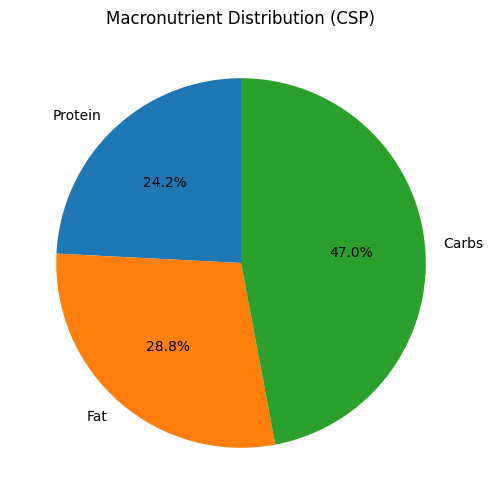

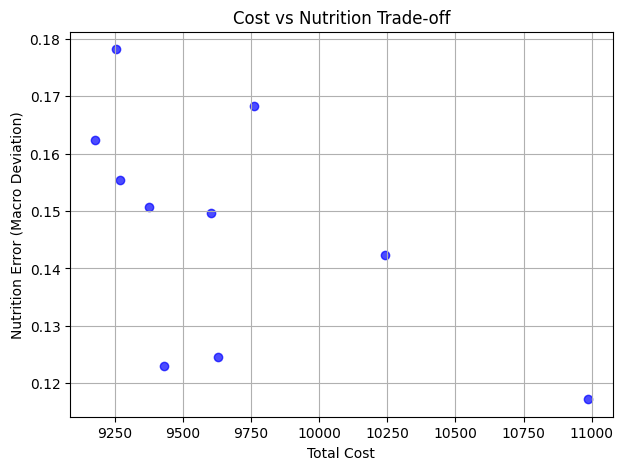

In [67]:
def get_axis_plot(meals):
     costs = []
     errors = []
     i = 16000
     for _ in range(10):
        solution = CSPproblem(2000,i,TransitionModel)
        s = solution.solve()
        cost = solution.get_total_cost(s)
        error = macro_error(meals,s)
        i += 1000
        costs.append(cost)
        errors.append(error)
     return costs,errors

meals_details = TransitionModel
labels = ['Protein', 'Fat', 'Carbs']
solution =  CSPproblem(2000,20000,TransitionModel)
values = get_macro_nutrition(meals_details,solution.solve())
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Macronutrient Distribution (CSP)')
plt.show()
x_axis,y_axis = get_axis_plot(meals_details)
plt.figure(figsize=(7,5))
plt.scatter(x_axis, y_axis, color='blue', alpha=0.7)
plt.xlabel("Total Cost")
plt.ylabel("Nutrition Error (Macro Deviation)")
plt.title("Cost vs Nutrition Trade-off")
plt.grid(True)
plt.show()